# Canny edge detector
## Naive Impelmenation

In [3]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

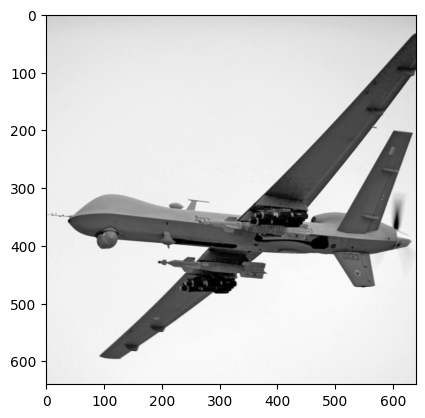

In [4]:
# load image and preprocess
image_png = Image.open("./image.png")

transform1 = transforms.ToTensor()
transform2 = transforms.Resize((640, 640))
image_orig = transform2(transform1(image_png))

# to grayscale
gs_img = image_orig[0] * 0.299 + image_orig[1] * 0.587 + image_orig[2] * 0.114
plt.imshow(gs_img, cmap="grey", vmin=0, vmax=1)


## Gaussian Blur

In [5]:
# gaussian blur implementation from scratch, without nn.conv
def gaussian_blur(input_image, kernel_size=3,sigma=3):
    # define kernel and filter
    kernel = torch.zeros(kernel_size, kernel_size, 2)
    gaussian_filter = torch.zeros(kernel_size, kernel_size)
    
    # index_prep = useful variable for calculations in order to work with kernel sizes and paddings
    index_prep = kernel_size // 2
    for i in range(kernel_size):
        for j in range(kernel_size):
            kernel[i,j] = torch.tensor([ 0 + j - index_prep  , 0 + i - index_prep ])

    # create gaussian filter with Gaussian Function
    for row in range(kernel_size):
        for column in range(kernel_size):
            gaussian_filter[row][column] = 1 / (2 * torch.pi * sigma**2) * torch.exp( - ( kernel[row][column][0] ** 2 + kernel[row][column][1] ** 2) / (2 * sigma**2))
    
    # normalasing gaussian filter
    gaussian_filter = gaussian_filter / gaussian_filter.sum()
    # we need to add padding in order to process border pixels
    # hard coded depending on kernel size k - 1
    padded_image = torch.zeros(input_image.shape[0] + kernel_size - 1, input_image.shape[1] + kernel_size - 1)
    
    # create actual new padded_image, hardcoded in terms of adding 0 paddings around
    padding = torch.zeros(index_prep)

    for i in range(input_image.shape[0]):
        padded_image[i + index_prep] = torch.concat((padding, input_image[i], padding))

    # output smoothed image
    smoothed_image = torch.zeros(input_image.shape[0], input_image.shape[1])

    # update the output image
    for row in range(0,input_image.shape[0]):
        for column in range(0,input_image.shape[1]):
            # Conv operation, but hardcoding for learning process
            # extract required matrix
            extracted_matrix = padded_image[row:row + kernel_size,column:column+kernel_size]
            # multiply
            multiplied = extracted_matrix * gaussian_filter
            # sum
            pixel_new_value = torch.sum(multiplied)
            # update
            smoothed_image[row][column] = pixel_new_value
    
    return smoothed_image
    
    
        
    

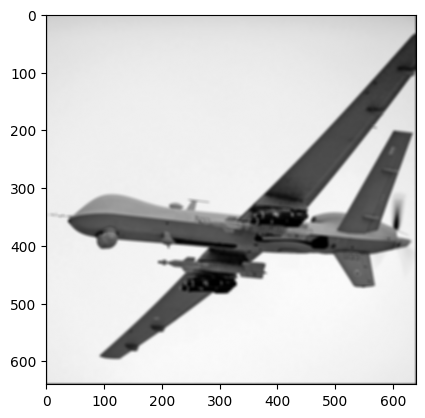

In [6]:
# blurred image
gaus_blur_image = gaussian_blur(gs_img, kernel_size=7, sigma=3)
plt.imshow(gaus_blur_image, cmap='grey', vmin=0, vmax=1)

## Compute the Image Gradient

In [7]:
def compute_gradient(input_image):

    # sobel X matris
    x_sobel = torch.tensor([
        [-1, 0 ,1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    # sobel Y matrix
    y_sobel = torch.tensor([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2 , 1]
    ])

    # padded image
    padded_image = torch.zeros(input_image.shape[0] + 2, input_image.shape[1] + 2)
    padding = torch.zeros(1)
    for i in range(input_image.shape[0]):
        padded_image[i + 1] = torch.concat((padding, input_image[i], padding))


    # output smoothed image
    output_gradient_magnitue = torch.zeros(input_image.shape[0], input_image.shape[1])
    output_gradient_direction = torch.zeros(input_image.shape[0], input_image.shape[1])

    # update the output image
    for row in range(0,input_image.shape[0]):
        for column in range(0,input_image.shape[1]):
            # Conv operation, but hardcoding for learning process
            # extract required matrix
            extracted_matrix = padded_image[row:row + 3,column:column+3]

            # get sobel multiplication matrixes
            Gx = torch.sum(extracted_matrix * x_sobel)

            Gy = torch.sum(extracted_matrix * y_sobel)

            # update
            output_gradient_magnitue[row][column] = torch.sqrt( Gx **2 + Gy ** 2)
            output_gradient_direction[row][column] = torch.arctan2(Gy, Gx)
        
    return output_gradient_magnitue, output_gradient_direction

In [8]:
# compute gradient
gradient_magnitue, gradient_direction = compute_gradient(gaus_blur_image)

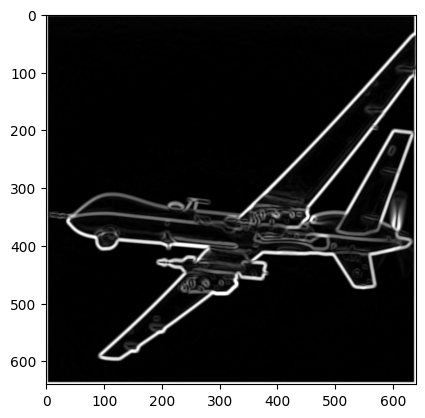

In [9]:
# gradient magnitue
plt.imshow(gradient_magnitue, cmap='grey', vmin=0, vmax=1)

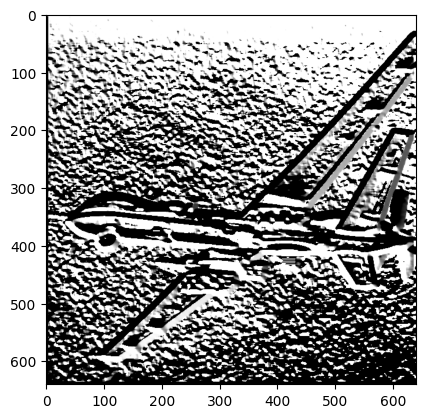

In [10]:
# gradient direction
plt.imshow(gradient_direction, cmap='grey', vmin=0, vmax=1)

## Non-Maximum Suppression

In [11]:
def non_maximum_suppresion(g_magnitue, g_direction):

    # values for calculating adjacent pixels values
    # will find closest to certain angle
    distance_val = torch.tensor([0,180, 45, 225, 90, 270, 135, 315])
    postionoal_val = ["Hor","Hor", "Diag_45", "Diag_45", "Vert", "Vert", "Diag_135", "Diag_135"]

    # output image
    non_max_supp_img = torch.zeros(g_magnitue.shape[0], g_magnitue.shape[1])

    # creating extra padding for gradient_magnitue
    gradient_magnitue_padded = torch.zeros(g_magnitue.shape[0] + 2, g_magnitue.shape[1] + 2)
    for i in range(g_magnitue.shape[0]):
        gradient_magnitue_padded[i + 1] = torch.concat((torch.zeros(1), g_magnitue[i], torch.zeros(1)))
    
    # calculating if magnitude in P[i,j] is bigger then both adjacent pixels based on gradient direction
    for i in range(0, g_direction.shape[0]):
        for j in range(0, g_direction.shape[1]):

            value = g_direction[i,j]

            # converting to degrees
            angle_value = 180 / torch.pi * value

            # subtracting from distance map, finding the index of minimum (which means it's closest), and retrieving the right gradient direction 
            grad_direction_tye = postionoal_val[torch.argmin(torch.abs(distance_val - angle_value))]
            
            # get values for padding image
            p_i = i + 1
            p_j = j + 1
            if grad_direction_tye == 'Hor':
                # get adjacent values for left and right pixel
                ajc1 = gradient_magnitue_padded[p_i,p_j + 1]
                ajc2 = gradient_magnitue_padded[p_i,p_j - 1]            
            if grad_direction_tye == 'Diag_45':
                # get dadjacent value for right top and left bottom pixel
                ajc1 = gradient_magnitue_padded[p_i + 1,p_j + 1]
                ajc2 = gradient_magnitue_padded[p_i - 1,p_j - 1]
            if grad_direction_tye == 'Vert':
                # get dadjacent value for top and bottom pixel
                ajc1 = gradient_magnitue_padded[p_i + 1,p_j]
                ajc2 = gradient_magnitue_padded[p_i + 1,p_j]
            if grad_direction_tye == 'Diag_135':
                # get adjacent value for top right and top left pixel 
                ajc1 = gradient_magnitue_padded[p_i + 1,p_j - 1]
                ajc2 = gradient_magnitue_padded[p_i - 1,p_j + 1]
            
            # check if gradient magnitue pixel is bigger then both adjacent pixels
            if g_magnitue[i, j] >= ajc1 and g_magnitue[i, j] >= ajc2:
                non_max_supp_img[i, j] = g_magnitue[i, j]
            else:
            # if no, then 0
                non_max_supp_img[i, j] = 0
    
    return non_max_supp_img
    
    

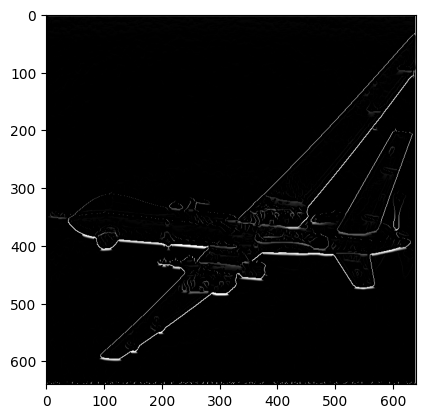

In [12]:
non_max_img = non_maximum_suppresion(gradient_magnitue, gradient_direction)
plt.imshow(non_max_img, cmap='grey', vmin=0, vmax=1)

## Double Thresholding

In [13]:
def double_thresholding(non_sup_magnit, low_thresh = 0.15, high_thresh = 0.30):
    # prepare output image
    output_image = torch.zeros(non_sup_magnit.shape[0], non_sup_magnit.shape[1])

    # update values based on threshold
    for i in range(non_sup_magnit.shape[0]):
        for j in range(non_sup_magnit.shape[1]):
            p = non_sup_magnit[i,j]
            if p < low_thresh:
                output_image[i,j] = 0
            elif p > high_thresh:
                output_image[i,j] = 1
            else:
                output_image[i,j] = 0.5
    
    return output_image


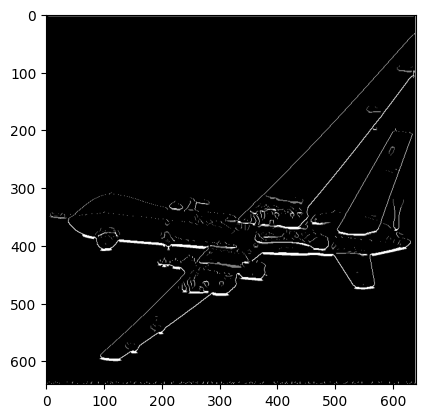

In [14]:
threshold_img = double_thresholding(non_max_img)
plt.imshow(threshold_img, cmap='grey', vmin=0, vmax=1)

## Edge Tracking by Hysteresis

In [15]:
def edge_hysteris(thresholded_image):

    # prepare output image
    output_image = torch.zeros(thresholded_image.shape[0], thresholded_image.shape[1])

    # creating extra padding for hysteris
    thresholded_image_padded = torch.zeros(thresholded_image.shape[0] + 2, thresholded_image.shape[1] + 2)
    for i in range(thresholded_image.shape[0]):
        thresholded_image_padded[i + 1] = torch.concat((torch.zeros(1), thresholded_image[i], torch.zeros(1)))


    for i in range(0, thresholded_image.shape[0]):
        for j in range(0, thresholded_image.shape[1]):
            # to work with pagged image
            p_i = i + 1
            p_j = j + 1

            p_p = thresholded_image_padded[p_i, p_j]

            # check if weak pixel surrounding pixels are strong (at least one) and to assign it to strong pixel
            if p_p == 0.5:
                surround_pixels = torch.tensor([
                    thresholded_image_padded[p_i - 1, p_j - 1], thresholded_image_padded[p_i - 1, p_j], thresholded_image_padded[p_i - 1, p_j + 1],
                    thresholded_image_padded[p_i, p_j - 1],  thresholded_image_padded[p_i, p_j + 1],
                    thresholded_image_padded[p_i + 1, p_j - 1], thresholded_image_padded[p_i + 1, p_j], thresholded_image_padded[p_i + 1, p_j + 1],
                ])

                if torch.any(surround_pixels == 1):
                    output_image[i,j] = 1
                else:
                    output_image[i,j] = 0
            
            # leave it if it's strong
            if p_p == 1:
                output_image[i,j] = 1
        
    return output_image
                    


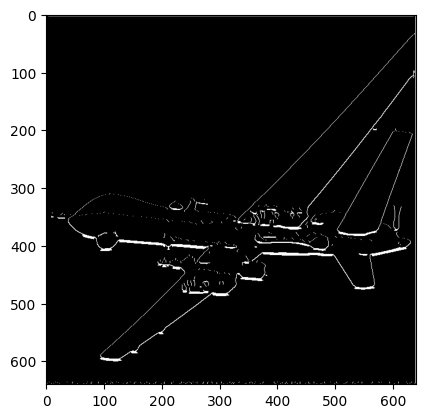

In [16]:
out = edge_hysteris(threshold_img)
plt.imshow(out, cmap='grey', vmin=0, vmax=1)